# Práctica 2: Modelo cinemático inverso de un manipulador y planteamiento de trayectoria


## Objetivo



El objetivo de esta práctica es que el alumno comprenda, interprete y modifique el modelo de cinemática directa e inversa d eun moanipulador serial.


### Metas 

- Que el alumno aplique un modelo cinemático, obteniendo las matrices de transformación y la postura del manipulador 
- Que el alumno aplique un modelo cinemático inverso para calcular una trayectoria a partir de una posición actual hacia una posición final
- Que el alumno grafique y analice los resultados del modelo

### Contribución al perfil del egresado

La siguiente práctica contribuye en los siguientes puntos al perfil del egresado:

#### Aptitudes y habilidades

- Para modelar, simular e interpretar el comportamiento de los sistemas mecatrónicos.
- Para diseñar, construir, operar y mantener los sistemas mecatrónicos y sus componentes.

#### Actitudes

- Tener confianza en su preparación académica.
- Comprometido con su actualización, superación y competencia profesional.

#### De tipo social

- Promover el cambio en la mentalidad frente a la competitividad internacional.



## Rúbrica de evaluación



La evaluación de la práctica contará de los siguientes puntos y se evaluará con los siguientes criterios:

| Elemento | Porcentaje |
| ------:| -----------:|
| **Cuestionario previo** | 15% | 
| **Desarrollo** | 35% |
| **Análisis de resultados**  | 35% |
| **Conclusiones** | 15% |

<br>


| Elemento | Malo | Regular | Bueno |
| ------:| ------ | --------| ------|
| **Cuestionario previo** | El trabajo no contiene cuestionario previo o todas las preguntas son incorrectas (0%)| Al menos la mitad de las preguntas son correctas (8%) |  Todas las preguntas son correctas (15%) |
| **Desarrollo** | El trabajo no contiene desarrollo o su planteamiento no concuerda con lo deseado (0%) | El desarrollo está mal planteado o no llega a los resultados esperados (10%) | El desarrollo tiene un planteamiento adecuado y llega a los resultados esperados (35%) |
| **Análisis de resultados**  | El trabajo no contiene análisis de resultados o la información no se está interpretando correctamente (0%) | La interpretación de los resultados es parcial o desorganizada (10%) | Realiza un correcto análisis de los resultados de forma organizada   (35%) |
| **Conclusiones** | El trabajo no contiene conclusiones o no hacen referencia al trabajo desarrollado y los objetivos planteados (0%) | La redacción de las conclusiones es desorganizada o confusa (8%) | Las conclusiones del trabajo son claras y hacen referencia al trabajo desarrollado y los objetivos planteados (15%) | 



## Introducción

### Transformaciones homogéneas
Las transformaciones homogéneas permiten hacer el planteamiento del modelo cinemático de un robot, considerando las posiciones y orientaciones de las juntas del robot respecto al sistema de referencia de una junta anterior

Este planteamiento es el **modelo de cinemática directa**, que nos permite obtener la posición y velocidad del efector final de un manipulador en términos de los valores de la posición y velocidad de sus juntas (espacio de trabajo)

A través de este modelo se puede obtener el **modelo de cinemática inversa**, que permite obtener la velocidad de las juntas de un robot a partir de la velocidad deseada del efector final.

### Planteamiento de una trayectoria
Si se conoce el punto inicial y final de una trayectoria deseada, se pueden obtener los puntos intermedios de la trayectoria. La forma más fácil de realizar esta interpolación es a través de un spline. El orden del spline permitirá controlar las condiciones inicial y final de la posición, velocidad ó aceleración que tendrá el efector final durante el trayecto. 

Juntando la interpolación de la trayectoria y el modelo de la cinemática inversa, se pueden obtener todos los puntos intermedios de la trayectoria que deben seguir las juntas del robot para que el efector final siga una trayectoria.

### Inyección de dependencias en python
Al crear una clase, es posible agregar atributos y métodos a la misma, que se verán reflejados al instanciar un objeto, por ejemplo:

In [1]:
# Se define una clase
class ClaseEjemplo():
  def metodo_original(self):
    print("Metodo original")
# Fuera de la clase, se define un método nuevo
def metodo_inyectado(self):
  print("Método inyectado en la clase")
# Se asigna el método dentro de la clase
ClaseEjemplo.nuevo_metodo = metodo_inyectado
# Al instanciar el objeto, éste contiene el método inyectado
objeto = ClaseEjemplo()
objeto.nuevo_metodo()

Método inyectado en la clase


## Cuestionario previo


Responder de forma breve las siguientes preguntas:

- ¿Qué son las transformaciones homogéneas?

> Las transformaciones homogéneas son matrices que permiten representar de forma conjunta la rotación y la traslación entre sistemas de referencia. En robótica se utilizan para describir la posición y orientación de cada eslabón respecto al anterior, facilitando el planteamiento de la cinemática directa de un manipulador.

- ¿Qué nos permite obtener el modelo de cinemática directa de un manipulador?

> El modelo de cinemática directa permite obtener la posición y orientación del efector final a partir de los valores conocidos de las variables articulares del robot. En un manipulador RRR, esto significa calcular la postura del efector final a partir de los ángulos de sus tres juntas rotacionales.

- ¿Qué nos permite obtener el modelo de cinemática inversa de un manipulador?

> El modelo de cinemática inversa permite obtener las variables articulares necesarias para que el efector final alcance una posición y orientación deseadas. En esta práctica se utiliza el Jacobiano inverso para relacionar las velocidades del efector final con las velocidades articulares del robot.

- ¿De qué formas se puede interpolar la trayectoria de un efector final entre dos puntos?

> La trayectoria de un efector final puede interpolarse mediante métodos lineales, polinomiales o splines. En robótica se utilizan con frecuencia polinomios cúbicos y de quinto grado; estos últimos permiten imponer condiciones de posición, velocidad y aceleración al inicio y al final del movimiento.


## Desarrollo



### 1. Planteamiento de la cinemática directa
En esta primera parte, se crearán las transformaciones homogéneas y el modelo de cinemática directa de un robot RRR, incluyendo la matriz del Jacobiano. Se recomienda usar **Sympy** para el planteamiento de las expresiones. 
Un diagrama del robot se muestra en la imagen:

<img src="imagenes/p2_1.png" alt = "Robot RRR" width="300" height="300" display= "block"/>

** Considerar valores cualesquiera para las dimensiones de los eslabones y la posición inicial de las juntas

In [2]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt

# Definición de la clase Robot adaptada al plano X-Y de la imagen
class RobotXY():
    def __init__(self, l=(0.3, 0.3, 0.3)):
        # 1. Definición de símbolos
        th1, th2, th3 = sp.symbols("theta_1, theta_2, theta_3")
        
        # 2. Matrices de transformación homogénea (Rotaciones puras en Z con traslaciones en X)
        # Nota: Usamos tu función tr_h original para construir la cadena cinemática
        T_0_1 = self.tr_h(alpha=th1)
        T_1_2 = self.tr_h(x=l[0], alpha=th2)
        T_2_3 = self.tr_h(x=l[1], alpha=th3)
        T_3_p = self.tr_h(x=l[2])
        
        # Transformación total desde la base {0} hasta el efector final {P}
        T_0_p = sp.simplify(T_0_1 * T_1_2 * T_2_3 * T_3_p)
        
        # 3. Vector de postura modificado para el plano X-Y (según la imagen)
        # T_0_p[0, 3] es la posición en X
        # T_0_p[1, 3] es la posición en Y (en kinematics.py original tenías T_0_p[2, 3] que es Z)
        xi_0_p = sp.Matrix([T_0_p[0, 3],
                            T_0_p[1, 3],
                            th1 + th2 + th3])
        
        # 4. Cálculo del Jacobiano geométrico
        J = sp.Matrix([[sp.diff(xi_0_p[0], th1), sp.diff(xi_0_p[0], th2), sp.diff(xi_0_p[0], th3)],
                       [sp.diff(xi_0_p[1], th1), sp.diff(xi_0_p[1], th2), sp.diff(xi_0_p[1], th3)],
                       [sp.diff(xi_0_p[2], th1), sp.diff(xi_0_p[2], th2), sp.diff(xi_0_p[2], th3)]])
        
        J_inv = J.inv()
        
        # Almacenar variables y matrices en el objeto
        self.th1, self.th2, self.th3 = th1, th2, th3
        self.T_0_1 = T_0_1
        self.T_1_2 = T_1_2
        self.T_2_3 = T_2_3
        self.T_3_p = T_3_p
        self.T_0_p = T_0_p
        self.xi_0_p = xi_0_p
        self.J = J
        self.J_inv = J_inv
        self.x_dot, self.y_dot, self.beta_dot = sp.symbols("x_dot, y_dot, beta_dot")
        
        # Variables para la trayectoria quintica
        t = sp.symbols("t")
        a_0, a_1, a_2, a_3, a_4, a_5 = sp.symbols("a_0, a_1, a_2, a_3, a_4, a_5")
        lam = a_0 + a_1 * t + a_2 * t**2 + a_3 * t**3 + a_4 * t**4 + a_5 * t**5    
        self.t = t
        self.lam, self.lam_dot, self.lam_dot_dot = lam, sp.diff(lam, t), sp.diff(sp.diff(lam, t), t)
        self.a_0, self.a_1, self.a_2, self.a_3, self.a_4, self.a_5 = a_0, a_1, a_2, a_3, a_4, a_5

    def tr_h(self, x=0, y=0, z=0, gamma=0, beta=0, alpha=0):
        t_x = sp.Matrix([[1,          0,           0, x],
                         [0, sp.cos(gamma), -sp.sin(gamma), 0],
                         [0, sp.sin(gamma),  sp.cos(gamma), 0],
                         [0,          0,           0, 1]])
        t_y = sp.Matrix([[ sp.cos(beta),          0, sp.sin(beta), 0],
                         [         0,          1,         0, y],
                         [-sp.sin(beta),          0, sp.cos(beta), 0],
                         [         0,          0,         0, 1]])
        t_z = sp.Matrix([[sp.cos(alpha), -sp.sin(alpha), 0, 0],
                         [sp.sin(alpha),  sp.cos(alpha), 0, 0],
                         [         0,           0, 1, z],
                         [         0,           0, 0, 1]])
        return sp.simplify(t_x * t_y * t_z)

# Instanciamos el robot para verificar que la cinemática directa funciona
robot = RobotXY(l=(0.4, 0.3, 0.2)) # Longitudes de eslabones de ejemplo
print("Expresión de la Postura del Efector Final (X, Y, Beta):")
sp.pprint(robot.xi_0_p)

Expresión de la Postura del Efector Final (X, Y, Beta):
⎡0.4⋅cos(θ₁) + 0.3⋅cos(θ₁ + θ₂) + 0.2⋅cos(θ₁ + θ₂ + θ₃)⎤
⎢                                                      ⎥
⎢0.4⋅sin(θ₁) + 0.3⋅sin(θ₁ + θ₂) + 0.2⋅sin(θ₁ + θ₂ + θ₃)⎥
⎢                                                      ⎥
⎣                     θ₁ + θ₂ + θ₃                     ⎦


### 2. Planteamiento de la trayectoria

En esta segunda parte, se planteará el código que permita definir los puntos intermedios de una trayectoria, la cual debe tener velocidades y aceleraciones nulas al inicio y al final. Se deben incluir también las gráficas de la posición, velocidad y aceleración del efector final. 

Calcular la trayectoria considerando de forma general tiempo de duración, puntos inicial y final, y con una tasa de muestreo de 30 muestras por segundo. 

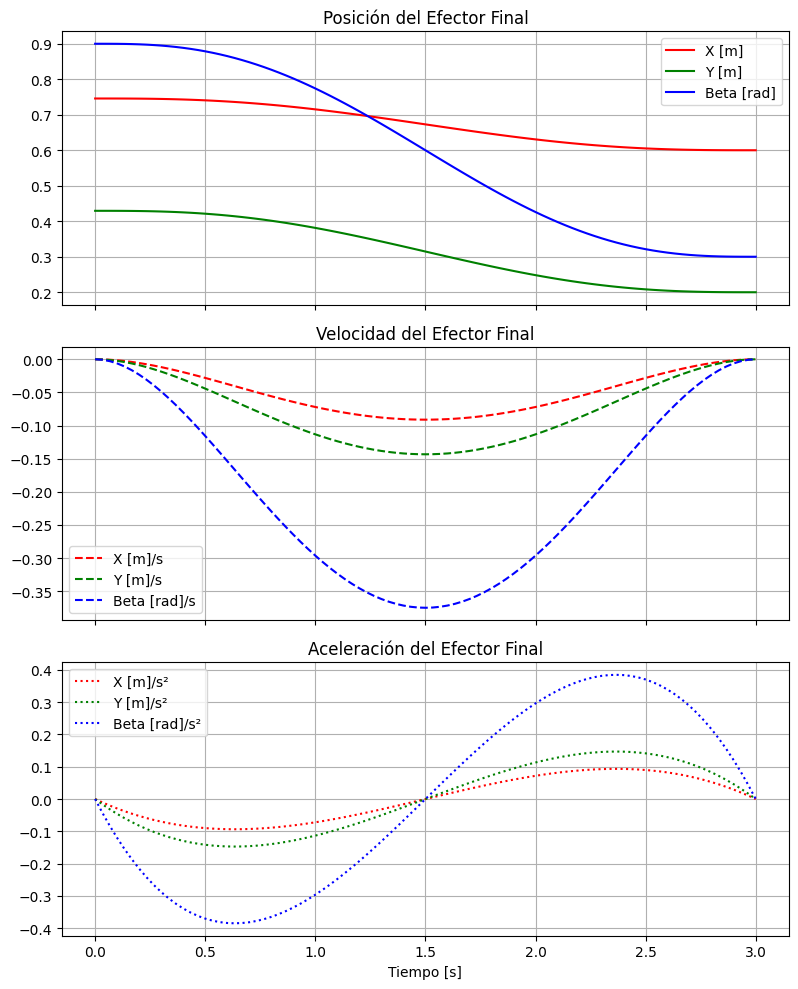

In [3]:
# Inyección o definición del método de trayectoria en el notebook
def calcular_y_graficar_trayectoria(robot, t_f=3.0, frec=30, th_i=(0.1, 0.2, 0.1), xi_f=(0.5, 0.3, 0.5)):
    # 1. Posición inicial real calculada con cinemática directa
    xi_i = robot.xi_0_p.subs({robot.th1: th_i[0], robot.th2: th_i[1], robot.th3: th_i[2]})
    
    # Parámetros de tiempo y muestreo (30 muestras por segundo requerido)
    robot.dt = 1.0 / frec
    robot.muestras = int(t_f * frec) + 1
    t_m = np.linspace(0, t_f, robot.muestras)
    
    # 2. Ecuaciones de restricción para condiciones iniciales y finales nulas
    eq1 = robot.lam.subs({robot.t: 0})
    eq2 = robot.lam.subs({robot.t: t_f}) - 1
    eq3 = robot.lam_dot.subs({robot.t: 0})
    eq4 = robot.lam_dot.subs({robot.t: t_f})
    eq5 = robot.lam_dot_dot.subs({robot.t: 0})
    eq6 = robot.lam_dot_dot.subs({robot.t: t_f})
    
    sol = sp.solve((eq1, eq2, eq3, eq4, eq5, eq6), (robot.a_0, robot.a_1, robot.a_2, robot.a_3, robot.a_4, robot.a_5))
    
    # Sustituir coeficientes en las funciones temporales
    lam_s = robot.lam.subs(sol)
    lam_dot_s = robot.lam_dot.subs(sol)
    lam_dot_dot_s = robot.lam_dot_dot.subs(sol)
    
    # Expresiones operacionales del efector final
    xi_f_mat = sp.Matrix(xi_f)
    xi_eq = xi_i + (xi_f_mat - xi_i) * lam_s
    xi_dot_eq = (xi_f_mat - xi_i) * lam_dot_s
    xi_dot_dot_eq = (xi_f_mat - xi_i) * lam_dot_dot_s
    
    # 3. Evaluación numérica en los puntos de muestreo
    xi_m = np.zeros((3, robot.muestras))
    xi_dot_m = np.zeros((3, robot.muestras))
    xi_dot_dot_m = np.zeros((3, robot.muestras))
    
    for i, t_val in enumerate(t_m):
        xi_m[:, i] = np.array(xi_eq.subs({robot.t: t_val})).astype(np.float64).flatten()
        xi_dot_m[:, i] = np.array(xi_dot_eq.subs({robot.t: t_val})).astype(np.float64).flatten()
        xi_dot_dot_m[:, i] = np.array(xi_dot_dot_eq.subs({robot.t: t_val})).astype(np.float64).flatten()
        
    # Guardamos los resultados numéricos en el objeto robot
    robot.t_m = t_m
    robot.xi_m = xi_m
    robot.xi_dot_m = xi_dot_m
    robot.xi_dot_dot_m = xi_dot_dot_m
    
    # 4. Gráficas del Efector Final
    fig, axs = plt.subplots(3, 1, figsize=(8, 10), sharex=True)
    labels = ['X [m]', 'Y [m]', 'Beta [rad]']
    colors = ['r', 'g', 'b']
    
    for i in range(3):
        axs[0].plot(t_m, xi_m[i, :], label=labels[i], color=colors[i])
        axs[1].plot(t_m, xi_dot_m[i, :], label=labels[i] + '/s', color=colors[i], linestyle='--')
        axs[2].plot(t_m, xi_dot_dot_m[i, :], label=labels[i] + '/s²', color=colors[i], linestyle=':')
        
    axs[0].set_title("Posición del Efector Final")
    axs[1].set_title("Velocidad del Efector Final")
    axs[2].set_title("Aceleración del Efector Final")
    for ax in axs:
        ax.grid(True)
        ax.legend()
    plt.xlabel("Tiempo [s]")
    plt.tight_layout()
    plt.show()

# Ejecutar el cálculo y graficación de la trayectoria operacional
calcular_y_graficar_trayectoria(robot, t_f=3.0, frec=30, th_i=(0.2, 0.5, 0.2), xi_f=(0.6, 0.2, 0.3))

### 3. Cinemática inversa
A partir del modelo de la cinemática directa, obtener la expresión e la cinemática inversa, que relacione las velocidades de las juntas del robot con la velocidad del efector final. Ya que el modelo de cinemática inversa sólo permite obtener velocidades, obtener también expresiones que permitan obtener la posición de las juntas y sus aceleraciones

In [4]:
def resolver_cinematica_inversa_juntas(robot):
    # Ecuación de velocidades de las juntas simbólica (Inversa por Jacobiano)
    th_dot_eq = robot.J_inv * sp.Matrix([robot.x_dot, robot.y_dot, robot.beta_dot])
    
    # Inicialización de arreglos de almacenamiento
    th_m = np.zeros((3, robot.muestras))
    th_dot_m = np.zeros((3, robot.muestras))
    th_dot_dot_m = np.zeros((3, robot.muestras))
    
    # Asignamos la condición articular inicial dada en el paso anterior
    th_m[:, 0] = [0.2, 0.5, 0.2] 
    
    # Ciclo iterativo para calcular velocidades, posiciones (Método de Euler) y aceleraciones numéricas
    for i in range(robot.muestras):
        # Resolver velocidad articular actual substituyendo estados articulares y velocidades operacionales
        v_juntas = th_dot_eq.subs({
            robot.th1: th_m[0, i],
            robot.th2: th_m[1, i],
            robot.th3: th_m[2, i],
            robot.x_dot: robot.xi_dot_m[0, i],
            robot.y_dot: robot.xi_dot_m[1, i],
            robot.beta_dot: robot.xi_dot_m[2, i]
        })
        th_dot_m[:, i] = np.array(v_juntas).astype(np.float64).flatten()
        
        # Integración numérica para la siguiente posición de las juntas (Método de Euler)
        if i < robot.muestras - 1:
            th_m[:, i+1] = th_m[:, i] + th_dot_m[:, i] * robot.dt
            
        # Diferenciación numérica hacia atrás para obtener la aceleración articular
        if i > 0:
            th_dot_dot_m[:, i-1] = (th_dot_m[:, i] - th_dot_m[:, i-1]) / robot.dt
    
    # Ajuste de la última muestra de la aceleración para evitar ceros artificiales
    th_dot_dot_m[:, -1] = th_dot_dot_m[:, -2]

    # --- Gráficas de las variables de las Juntas ---
    fig, axs = plt.subplots(3, 1, figsize=(8, 10), sharex=True)
    juntas_labels = [r'$\theta_1$', r'$\theta_2$', r'$\theta_3$']
    colors = ['purple', 'orange', 'cyan']
    
    for i in range(3):
        axs[0].plot(robot.t_m, th_m[i, :], label=juntas_labels[i], color=colors[i])
        axs[1].plot(robot.t_m, th_dot_m[i, :], label=juntas_labels[i] + ' dot', color=colors[i], linestyle='--')
        axs[2].plot(robot.t_m, th_dot_dot_m[i, :], label=juntas_labels[i] + ' ddot', color=colors[i], linestyle=':')
        
    axs[0].set_title("Posiciones Articulares de las Juntas [rad]")
    axs[1].set_title("Velocidades Articulares de las Juntas [rad/s]")
    axs[2].set_title("Aceleraciones Articulares de las Juntas [rad/s²]")
    for ax in axs:
        ax.grid(True)
        ax.legend()
    plt.xlabel("Tiempo [s]")
    plt.tight_layout()
    plt.show()



### 4. Aplicación de la cinemática inversa
Finalmente, a partir de los puntos de la trayectoria y el modelo de cinemática inversa, obtener las posiciones, velocidades y aceleraciones de las juntas del robot, así como sus gráficas en función del tiempo

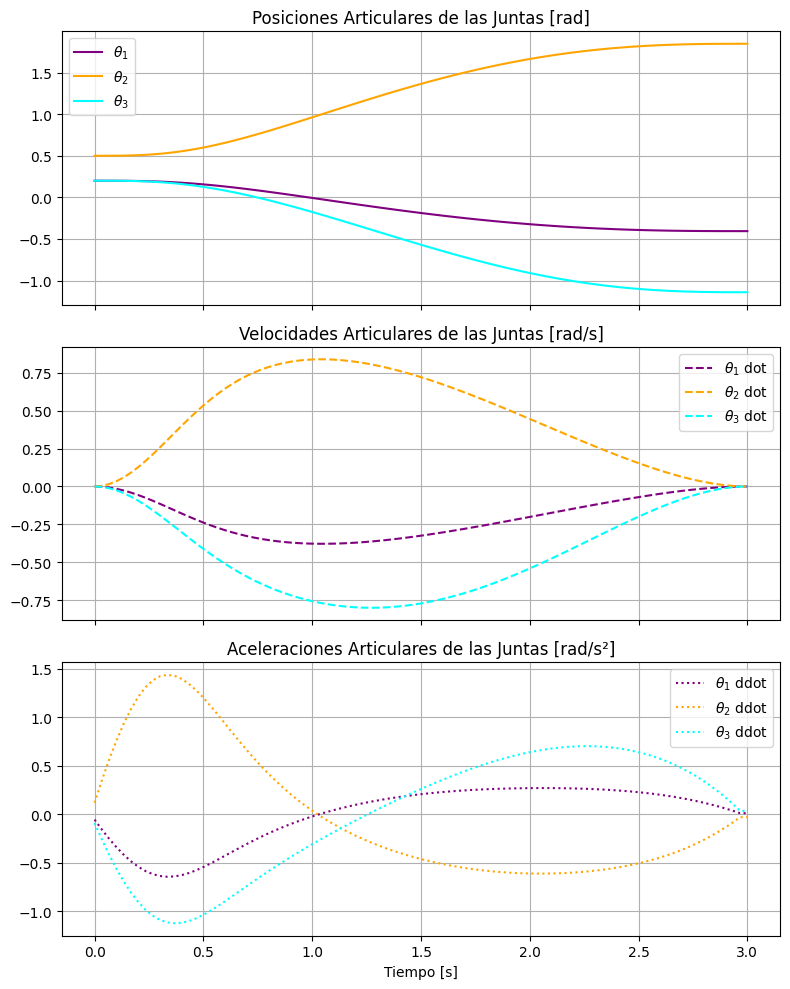

In [5]:
# Ejecutar el análisis e inversión cinemática
resolver_cinematica_inversa_juntas(robot)

### 5. Repositorio
Para terminar, subir los archivos de la práctica al repositorio de github

## Análisis de resultados


- ¿Qué utilidad tiene el modelo de cinemática inversa de un robot?

> El modelo de cinemática inversa es útil porque permite determinar los valores articulares necesarios para que el efector final de un robot siga una posición, orientación o trayectoria deseada. En esta práctica, a partir de la trayectoria planteada en el espacio operacional del efector final, se utilizó el Jacobiano inverso para calcular las velocidades articulares correspondientes.
>
> Las gráficas obtenidas permiten observar cómo cambian la posición, velocidad y aceleración de cada junta durante el movimiento. Además, el uso de una interpolación de quinto grado permitió generar una trayectoria suave, con velocidad y aceleración nulas al inicio y al final, lo cual es importante para evitar movimientos bruscos en un manipulador real.


## Conclusiones


> En esta práctica se desarrolló el modelo cinemático directo e inverso de un manipulador serial tipo RRR. A partir de matrices de transformación homogénea se obtuvo la postura del efector final en función de las variables articulares del robot.
>
> También se calculó la matriz Jacobiana, la cual permitió relacionar la velocidad del efector final con las velocidades de las juntas. Mediante el uso del Jacobiano inverso fue posible estimar las velocidades articulares necesarias para seguir una trayectoria definida en el espacio operacional.
>
> La trayectoria fue planteada mediante un polinomio de quinto grado, lo que permitió establecer condiciones de velocidad y aceleración nulas al inicio y al final del movimiento. Finalmente, las gráficas obtenidas permitieron analizar el comportamiento de la posición, velocidad y aceleración tanto del efector final como de las juntas del robot.



## Bibliografía 


[1] J. J. Craig, *Introduction to Robotics: Mechanics and Control*, 4th ed. Pearson, 2018.

[2] M. W. Spong, S. Hutchinson, and M. Vidyasagar, *Robot Modeling and Control*. Hoboken, NJ, USA: Wiley, 2006.

[3] B. Siciliano, L. Sciavicco, L. Villani, and G. Oriolo, *Robotics: Modelling, Planning and Control*. London, UK: Springer, 2009.

[4] SymPy Development Team, “SymPy documentation.” [En línea]. Disponible en: https://docs.sympy.org/
